# Capstone Project — Predicting 30-Day Hospital Readmission Risk

## Problem Statement
This notebook builds an end-to-end machine learning pipeline to predict whether a patient will be **readmitted within 30 days** of discharge.

### Target transformation
The original `readmitted` column contains:
- `<30`
- `>30`
- `NO`

It is transformed into a binary target:
- `1` = readmitted within 30 days
- `0` = not readmitted within 30 days

## Capstone alignment
This notebook is organized in three phases:

### Phase 1 — Data Processing
- data cleaning
- handling missing values
- exploratory data analysis (EDA)
- categorical encoding
- feature scaling
- stratified train/test split

### Phase 2 — Machine Learning
- compare multiple models:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - Neural Network (MLPClassifier)
- 5-fold cross-validation
- precision / recall / F1 / ROC-AUC
- hyperparameter tuning with `RandomizedSearchCV`

### Phase 3 — Generative AI
- build a simple patient-level prompt grounded in model outputs
- generate a structured clinical-style summary
- document governance limits: GenAI is **not** used to make predictions

## 1) Imports and configuration

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

try:
    import joblib
except ImportError:
    joblib = None

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)


## 2) Load the public dataset

- Expected local file path: `data/diabetic_data.csv`
- If the file is not found, download the **Diabetes 130-US hospitals for years 1999–2008** dataset
and place `diabetic_data.csv` inside the `data/` folder.


In [ ]:
DATA_PATH = os.path.join("data", "diabetic_data.csv")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Place 'diabetic_data.csv' inside the data/ folder before running the notebook."
    )

df_raw = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)
display(df_raw.head())

Dataset loaded successfully.
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3) Data Quality Audit
In this section, we perform an initial data audit and exploratory analysis.

We examine :

• dataset structure and dimensions  
• data types  
• missing values (NaN and hidden '?')  
• duplicated rows  
• feature cardinality  
• numerical feature statistics  
• categorical feature distributions  
This step helps identify potential data quality issues before data cleaning and preprocessing.

In [ ]:
# Work on a copy
df = df_raw.copy()

# =========================
# 1. DATASET OVERVIEW
# =========================
print("=" * 70)
print("1. DATASET OVERVIEW")
print("=" * 70)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.head())

# =========================
# 2. DATA TYPES
# =========================
print("\n" + "=" * 70)
print("2. DATA TYPES")
print("=" * 70)
display(df.dtypes.to_frame("dtype"))

# =========================
# 3. GLOBAL DATA QUALITY SUMMARY
# =========================
print("\n" + "=" * 70)
print("3. GLOBAL DATA QUALITY SUMMARY")
print("=" * 70)

summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notnull().sum(),
    "missing_nan_count": df.isnull().sum(),
    "missing_nan_percent": ((df.isnull().sum() / len(df)) * 100).round(2),
    "unique_values": df.nunique(dropna=True)
})

display(summary.sort_values(by="missing_nan_count", ascending=False))

# =========================
# 4. MISSING VALUES (NaN)
# =========================
print("\n" + "=" * 70)
print("4. MISSING VALUES (NaN)")
print("=" * 70)

missing_nan = df.isnull().sum().to_frame("missing_nan_count")
missing_nan["missing_nan_percent"] = ((missing_nan["missing_nan_count"] / len(df)) * 100).round(2)

display(missing_nan.sort_values(by="missing_nan_count", ascending=False))

# =========================
# 5. HIDDEN MISSING VALUES CODED AS '?'
# =========================
print("\n" + "=" * 70)
print("5. HIDDEN MISSING VALUES CODED AS '?'")
print("=" * 70)

question_marks = (df.astype(str) == "?").sum().to_frame("question_mark_count")
question_marks["question_mark_percent"] = ((question_marks["question_mark_count"] / len(df)) * 100).round(2)

display(question_marks.sort_values(by="question_mark_count", ascending=False))

# =========================
# 6. COMBINED MISSING INDICATORS
# =========================
print("\n" + "=" * 70)
print("6. COMBINED MISSING INDICATORS (NaN + '?')")
print("=" * 70)

combined_missing = summary.copy()
combined_missing["question_mark_count"] = (df.astype(str) == "?").sum()
combined_missing["question_mark_percent"] = ((combined_missing["question_mark_count"] / len(df)) * 100).round(2)
combined_missing["total_missing_like_count"] = (
    combined_missing["missing_nan_count"] + combined_missing["question_mark_count"]
)
combined_missing["total_missing_like_percent"] = (
    (combined_missing["total_missing_like_count"] / len(df)) * 100
).round(2)

display(combined_missing.sort_values(by="total_missing_like_count", ascending=False))

# =========================
# 7. FEATURE CARDINALITY
# =========================
print("\n" + "=" * 70)
print("7. FEATURE CARDINALITY (NUMBER OF UNIQUE VALUES)")
print("=" * 70)

cardinality = df.nunique(dropna=True).to_frame("unique_values")
display(cardinality.sort_values(by="unique_values", ascending=True))

print("\nColumns with only 1 unique value:")
one_value_cols = cardinality[cardinality["unique_values"] <= 1]
display(one_value_cols)

# =========================
# 8. DUPLICATED ROWS
# =========================
print("\n" + "=" * 70)
print("8. DUPLICATED ROWS")
print("=" * 70)

duplicate_count = df.duplicated().sum()
duplicate_percent = round((duplicate_count / len(df)) * 100, 2)

print(f"Duplicated rows: {duplicate_count}")
print(f"Duplicated rows percent: {duplicate_percent}%")

# =========================
# 9. NUMERICAL VARIABLES SUMMARY
# =========================
print("\n" + "=" * 70)
print("9. NUMERICAL VARIABLES SUMMARY")
print("=" * 70)

num_df = df.select_dtypes(include=[np.number])

if not num_df.empty:
    numeric_summary = num_df.describe().T
    numeric_summary["missing_count"] = num_df.isnull().sum()
    numeric_summary["missing_percent"] = ((num_df.isnull().sum() / len(df)) * 100).round(2)
    display(numeric_summary)
else:
    print("No numerical columns found.")

# =========================
# 10. CATEGORICAL VARIABLES SUMMARY
# =========================
print("\n" + "=" * 70)
print("10. CATEGORICAL VARIABLES SUMMARY")
print("=" * 70)

cat_df = df.select_dtypes(include=["object", "category"])

if not cat_df.empty:
    categorical_summary = cat_df.describe().T
    categorical_summary["missing_nan_count"] = cat_df.isnull().sum()
    categorical_summary["question_mark_count"] = (cat_df.astype(str) == "?").sum()
    display(categorical_summary)
else:
    print("No categorical columns found.")

# =========================
# 11. TOP CATEGORIES PER CATEGORICAL COLUMN
# =========================
print("\n" + "=" * 70)
print("11. TOP CATEGORIES PER CATEGORICAL COLUMN")
print("=" * 70)

for col in cat_df.columns:
    print("\n" + "-" * 50)
    print(f"Column: {col}")
    print("-" * 50)
    display(df[col].value_counts(dropna=False).head(10).to_frame("count"))

# =========================
# 12. QUICK DATA QUALITY FLAGS
# =========================
print("\n" + "=" * 70)
print("12. QUICK DATA QUALITY FLAGS")
print("=" * 70)

flags = pd.DataFrame(index=df.columns)
flags["has_nan"] = df.isnull().sum() > 0
flags["has_question_mark"] = (df.astype(str) == "?").sum() > 0
flags["is_constant"] = df.nunique(dropna=True) <= 1
flags["high_cardinality"] = df.nunique(dropna=True) > 50

display(flags)

1. DATASET OVERVIEW
Rows: 101766
Columns: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO



2. DATA TYPES


,dtype
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64



3. GLOBAL DATA QUALITY SUMMARY


...

,count
diabetesMed,
Yes,78363
No,23403



--------------------------------------------------
Column: readmitted
--------------------------------------------------


,count
readmitted,
NO,54864
>30,35545
<30,11357



12. QUICK DATA QUALITY FLAGS


,has_nan,has_question_mark,is_constant,high_cardinality
encounter_id,False,False,False,True
patient_nbr,False,False,False,True
race,False,True,False,False
gender,False,False,False,False
age,False,False,False,False
weight,False,True,False,False
admission_type_id,False,False,False,False
discharge_disposition_id,False,False,False,False
admission_source_id,False,False,False,False
time_in_hospital,False,False,False,False


## 4) Data Cleaning and Target Definition
Based on the exploratory data analysis, several data quality issues were identified:

- some categorical columns use "?" as a placeholder for missing values
- some columns are identifiers and do not provide predictive value
- some features have a very high proportion of missing values
- the original target variable `readmitted` must be converted into a binary outcome for 30-day readmission prediction

To address these issues, we:
1. replace "?" with standard missing values (`NaN`)
2. remove identifier columns
3. remove high-missing columns
4. define the binary target:
   - 1 if `readmitted == "<30"`
   - 0 otherwise

In [ ]:
# ------------------------------
# 4.1 Remove obvious non-useful columns
# ------------------------------
cols_to_drop = ["encounter_id", "patient_nbr", "weight", "payer_code", "medical_specialty"]

existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

print("\nRemoved columns:")
print(existing_cols_to_drop)

# ------------------------------
# 4.2 Replace hidden missing values
# ------------------------------
df = df.replace("?", np.nan)

print("\nMissing values after replacing '?' with NaN (top 15):")
missing_after_replace = df.isnull().sum().sort_values(ascending=False)
display(missing_after_replace[missing_after_replace > 0].head(15).to_frame("missing_count"))

# ------------------------------
# 4.3 Define binary target
# ------------------------------
TARGET_COL = "readmitted"

# keep only rows with known target
df = df.dropna(subset=[TARGET_COL]).copy()

# create binary target
df["target_readmit_30"] = (df[TARGET_COL] == "<30").astype(int)

# optional: drop original target to avoid leakage later
df = df.drop(columns=[TARGET_COL])

# ------------------------------
# 4.4 Final check after cleaning
# ------------------------------
print("\nDataset shape after cleaning:", df.shape)

print("\nTarget distribution (count):")
display(df["target_readmit_30"].value_counts().sort_index().to_frame("count"))

print("\nTarget distribution (ratio):")
display(
    df["target_readmit_30"]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
    .to_frame("ratio")
)

print("\nRemaining missing values (top 15):")
remaining_missing = df.isnull().sum().sort_values(ascending=False)
display(remaining_missing[remaining_missing > 0].head(15).to_frame("missing_count"))

print("\nPreview of cleaned dataset:")
display(df.head())


Removed columns:
['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']

Missing values after replacing '?' with NaN (top 15):


,missing_count
max_glu_serum,96420
A1Cresult,84748
race,2273
diag_3,1423
diag_2,358
diag_1,21



Dataset shape after cleaning: (101766, 45)

Target distribution (count):


,count
target_readmit_30,
0,90409
1,11357



Target distribution (ratio):


,ratio
target_readmit_30,
0,0.8884
1,0.1116



Remaining missing values (top 15):


,missing_count
max_glu_serum,96420
A1Cresult,84748
race,2273
diag_3,1423
diag_2,358
diag_1,21



Preview of cleaned dataset:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target_readmit_30
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0


## 5) Feature Selection

After cleaning the dataset, we define a subset of features to be used for model training.

The selected variables include:

• healthcare utilization features (e.g., number of visits, medications, procedures)  
• demographic variables (age, gender, race)  
• diagnosis-related variables (diag_1, diag_2, diag_3)  
• admission and discharge information  
• diabetes treatment indicators (insulin, diabetesMed, change)

This subset keeps clinically relevant information while avoiding unnecessary variables that may introduce noise or leakage.

In [ ]:
candidate_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "insulin",
    "change",
    "diabetesMed"
]

# Check which columns exist
available_cols = [c for c in candidate_cols if c in df.columns]
missing_cols = [c for c in candidate_cols if c not in df.columns]

print("Number of selected features:", len(available_cols))
print("Missing columns:", missing_cols)

# Define features and target
X = df[available_cols].copy()
y = df["target_readmit_30"].copy()

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Number of selected features: 16
Missing columns: []

Feature matrix shape: (101766, 16)
Target shape: (101766,)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,insulin,change,diabetesMed
0,1,41,0,1,0,0,0,Caucasian,Female,[0-10),6,25,1,No,No,No
1,3,59,0,18,0,0,0,Caucasian,Female,[10-20),1,1,7,Up,Ch,Yes
2,2,11,5,13,2,0,1,AfricanAmerican,Female,[20-30),1,1,7,No,No,Yes
3,2,44,1,16,0,0,0,Caucasian,Male,[30-40),1,1,7,Up,Ch,Yes
4,1,51,0,8,0,0,0,Caucasian,Male,[40-50),1,1,7,Steady,Ch,Yes


## 6) Exploratory Data Analysis (EDA)

This section explores relationships between selected features and the binary target variable.

The goal is to better understand the dataset before training machine learning models and to identify potential predictors of 30-day hospital readmission.

We visualize:

- the distribution of the target variable
- key healthcare utilization variables by target class
- readmission patterns by age group
- readmission patterns by insulin treatment status



Target distribution


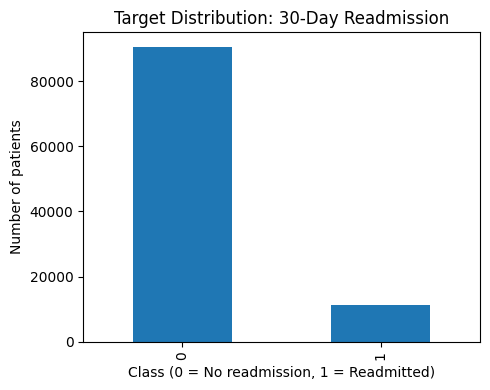


Key numeric variables by target


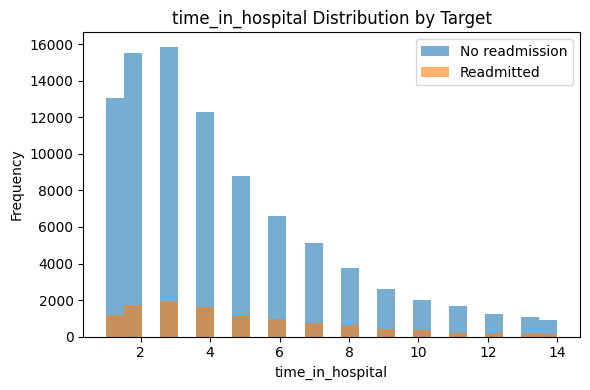

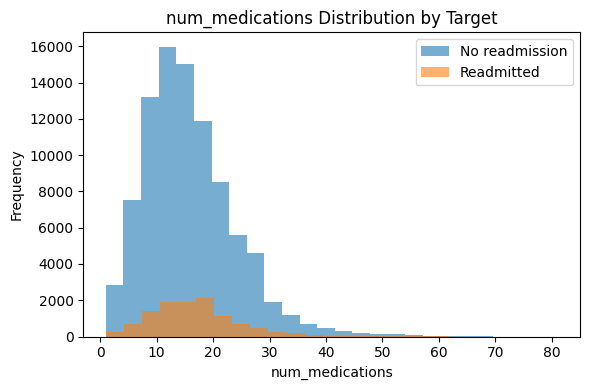

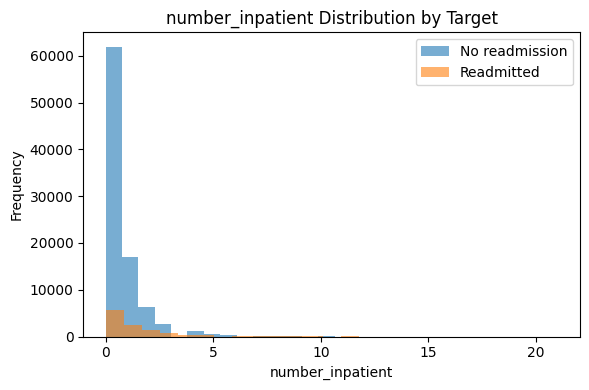


Readmission rate by age group


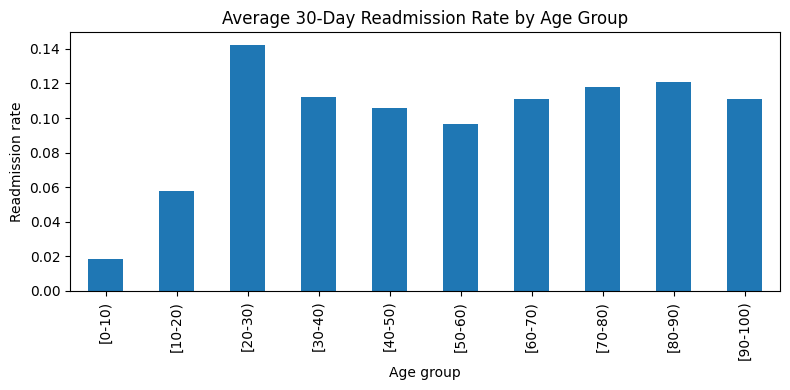


Readmission rate by insulin treatment


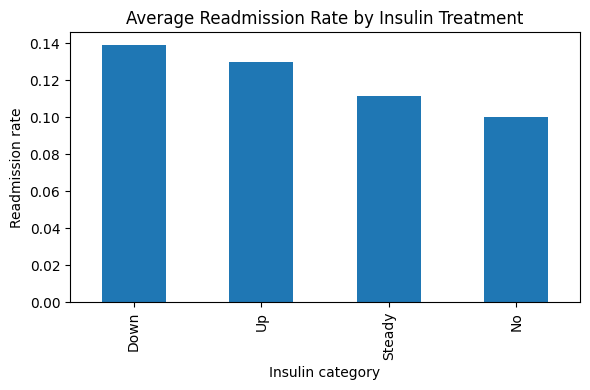

In [ ]:
# ----------------------------------------------------------
# 6.1 Target distribution
# ----------------------------------------------------------
print("\nTarget distribution")

fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().sort_index().plot(kind="bar", ax=ax)

ax.set_title("Target Distribution: 30-Day Readmission")
ax.set_xlabel("Class (0 = No readmission, 1 = Readmitted)")
ax.set_ylabel("Number of patients")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 6.2 Key numeric variables by target
# ----------------------------------------------------------
print("\nKey numeric variables by target")

numeric_cols = ["time_in_hospital", "num_medications", "number_inpatient"]

for col in numeric_cols:
    if col in X.columns:
        fig, ax = plt.subplots(figsize=(6, 4))

        X.loc[y == 0, col].dropna().plot(
            kind="hist",
            bins=25,
            alpha=0.6,
            label="No readmission",
            ax=ax
        )

        X.loc[y == 1, col].dropna().plot(
            kind="hist",
            bins=25,
            alpha=0.6,
            label="Readmitted",
            ax=ax
        )

        ax.set_title(f"{col} Distribution by Target")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        ax.legend()

        plt.tight_layout()
        plt.show()

# ----------------------------------------------------------
# 6.3 Readmission rate by age group
# ----------------------------------------------------------
if "age" in X.columns:
    print("\nReadmission rate by age group")

    age_readmit = (
        pd.DataFrame({"age": X["age"], "target": y})
        .groupby("age")["target"]
        .mean()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    age_readmit.plot(kind="bar", ax=ax)

    ax.set_title("Average 30-Day Readmission Rate by Age Group")
    ax.set_ylabel("Readmission rate")
    ax.set_xlabel("Age group")

    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------
# 6.4 Readmission rate by insulin treatment
# ----------------------------------------------------------
if "insulin" in X.columns:
    print("\nReadmission rate by insulin treatment")

    insulin_readmit = (
        pd.DataFrame({"insulin": X["insulin"], "target": y})
        .dropna()
        .groupby("insulin")["target"]
        .mean()
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    insulin_readmit.plot(kind="bar", ax=ax)

    ax.set_title("Average Readmission Rate by Insulin Treatment")
    ax.set_ylabel("Readmission rate")
    ax.set_xlabel("Insulin category")

    plt.tight_layout()
    plt.show()

## 7) Stratified Train/Test Split

To properly evaluate the machine learning models, the dataset is divided into a training set and a testing set.

Because the positive class (30-day readmission) is less frequent, we use a **stratified split** to preserve the class distribution in both subsets.

This ensures that the proportion of readmitted patients remains similar in the training and test datasets, which helps produce a more reliable evaluation of model performance.

In [ ]:
# Split dataset while preserving class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Display dataset shapes
print("\nDataset shapes")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

# Check class distribution
print("\nClass distribution check")

print("Train positive rate:", round(y_train.mean(), 4))
print("Test positive rate :", round(y_test.mean(), 4))


Dataset shapes
Train shape: (81412, 16)
Test shape : (20354, 16)

Class distribution check
Train positive rate: 0.1116
Test positive rate : 0.1116


## 8) Build the preprocessing pipeline

Before training machine learning models, the dataset must be properly preprocessed.

We build a preprocessing pipeline that automatically handles numeric and categorical features.

The pipeline performs the following operations:

• **Numeric features**
  - Missing values are filled using median imputation
  - Features are standardized using scaling

• **Categorical features**
  - Missing values are filled using the most frequent category
  - Categories are converted to numeric format using one-hot encoding

Using a pipeline ensures that preprocessing steps are applied consistently to both the training and test datasets.  
This also helps prevent data leakage and makes the workflow fully reproducible.


In [ ]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# ----------------------------------------------------------
# Numeric preprocessing
# ----------------------------------------------------------
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# ----------------------------------------------------------
# Categorical preprocessing
# ----------------------------------------------------------
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Compatibility with older scikit-learn versions
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot)
    ]
)

# ----------------------------------------------------------
# Combine preprocessing steps
# ----------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline successfully created.")

Numeric features: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']
Categorical features: ['race', 'gender', 'age', 'insulin', 'change', 'diabetesMed']

Preprocessing pipeline successfully created.


## 9) Compare Classification Models with 5-Fold Cross-Validation

In this section, we compare several classification algorithms using 5-fold stratified cross-validation on the training set.

The models evaluated are:

- Logistic Regression
- Random Forest
- Gradient Boosting
- Neural Network (MLPClassifier)

The following performance metrics are reported:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

For this healthcare prediction task, **recall** and **F1-score** are especially important because failing to identify high-risk patients may have important clinical consequences.


In [ ]:
# ----------------------------------------------------------
# Candidate models
# ----------------------------------------------------------
candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE
    )
}

# ----------------------------------------------------------
# Cross-validation strategy
# ----------------------------------------------------------
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ----------------------------------------------------------
# Evaluation metrics
# ----------------------------------------------------------
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# ----------------------------------------------------------
# Model comparison
# ----------------------------------------------------------
comparison_results = []

for model_name, model in candidate_models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    comparison_results.append({
        "model": model_name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_roc_auc_mean": scores["test_roc_auc"].mean()
    })

# ----------------------------------------------------------
# Results table
# ----------------------------------------------------------
results_df = pd.DataFrame(comparison_results)

results_df = results_df.sort_values(
    by=["cv_f1_mean", "cv_recall_mean", "cv_roc_auc_mean"],
    ascending=False
).reset_index(drop=True)

results_df = results_df.round(4)

display(results_df)

,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean
0,Logistic Regression,0.6740,0.1705,0.4970,0.2539,0.6380
1,MLP Neural Network,0.8885,0.5321,0.0110,0.0216,0.6402
2,Gradient Boosting,0.8885,0.5375,0.0090,0.0177,0.6658
3,Random Forest,0.8879,0.3805,0.0067,0.0132,0.6253


## 10) Hyperparameter Tuning with RandomizedSearchCV

After comparing the candidate models, we tune the best-performing model using `RandomizedSearchCV`.

This approach is more computationally efficient than an exhaustive grid search while still exploring multiple hyperparameter combinations.

The tuning process is based on **F1-score**, which is appropriate for this healthcare classification task because it balances precision and recall.

In [ ]:
# ----------------------------------------------------------
# Select best model from section 9
# ----------------------------------------------------------
best_model_name = results_df.loc[0, "model"]
print("Best model selected for tuning:", best_model_name)

# ----------------------------------------------------------
# Define model and parameter space
# ----------------------------------------------------------
if best_model_name == "Random Forest":
    base_model = RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    param_distributions = {
        "model__n_estimators": [100, 150, 200],
        "model__max_depth": [None, 8, 12, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    }

elif best_model_name == "Logistic Regression":
    base_model = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
    param_distributions = {
        "model__C": np.logspace(-2, 2, 8),
        "model__solver": ["lbfgs", "liblinear"]
    }

elif best_model_name == "Gradient Boosting":
    base_model = GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
    param_distributions = {
        "model__n_estimators": [100, 150, 200],
        "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4]
    }

else:
    raise ValueError("Unexpected best model name. Please check results_df.")

# ----------------------------------------------------------
# Build tuning pipeline
# ----------------------------------------------------------
tuning_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", base_model)
    ]
)

# ----------------------------------------------------------
# Randomized search
# ----------------------------------------------------------
random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=5,              # reduced for faster execution
    scoring="f1",
    cv=CV_FOLDS,            # use 3-fold CV if defined earlier
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

# ----------------------------------------------------------
# Best tuning results
# ----------------------------------------------------------
print("\nBest parameters:")
display(random_search.best_params_)

print("Best cross-validated F1-score:", round(random_search.best_score_, 4))

# Save best tuned model
best_model = random_search.best_estimator_

Best model selected for tuning: Logistic Regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters:


{'model__solver': 'lbfgs', 'model__C': np.float64(0.01)}

Best cross-validated F1-score: 0.253


## 11) Final Evaluation on the Held-Out Test Set

After selecting and tuning the best model, we evaluate its performance on the unseen test set.

The following outputs are reported:

- test-set performance metrics
- classification report
- confusion matrix
- ROC-AUC
- ROC curve

This final evaluation provides an estimate of how well the tuned model generalizes to new patient records.


Test metrics:
accuracy: 0.6742
precision: 0.1718
recall: 0.5024
f1: 0.2560
roc_auc: 0.6449

Classification report:
              precision    recall  f1-score   support

           0     0.9176    0.6958    0.7914     18083
           1     0.1718    0.5024    0.2560      2271

    accuracy                         0.6742     20354
   macro avg     0.5447    0.5991    0.5237     20354
weighted avg     0.8344    0.6742    0.7317     20354



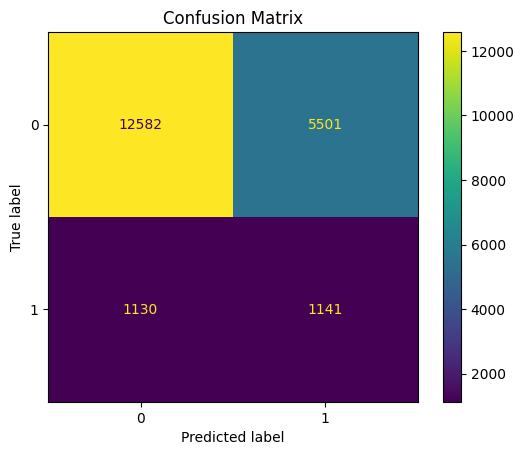

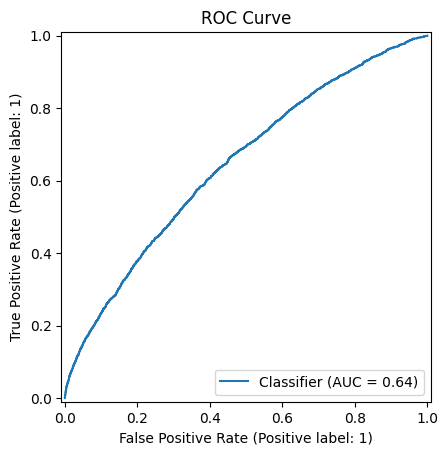

In [ ]:
# ----------------------------------------------------------
# Best tuned pipeline
# ----------------------------------------------------------
best_pipe = random_search.best_estimator_

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------
y_pred = best_pipe.predict(X_test)
y_proba = None

if hasattr(best_pipe.named_steps["model"], "predict_proba"):
    y_proba = best_pipe.predict_proba(X_test)[:, 1]

elif hasattr(best_pipe.named_steps["model"], "decision_function"):
    decision_values = best_pipe.decision_function(X_test)

    # Normalize values to [0,1] for ROC-AUC / ROC curve visualization
    y_proba = (
        (decision_values - decision_values.min()) /
        (decision_values.max() - decision_values.min() + 1e-12)
    )

# ----------------------------------------------------------
# Test metrics
# ----------------------------------------------------------
test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0)
}

if y_proba is not None:
    test_metrics["roc_auc"] = roc_auc_score(y_test, y_proba)

print("\nTest metrics:")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

# ----------------------------------------------------------
# Classification report
# ----------------------------------------------------------
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# ----------------------------------------------------------
# Confusion matrix
# ----------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ----------------------------------------------------------
# ROC curve
# ----------------------------------------------------------
if y_proba is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC Curve")
    plt.show()

## 12) Quick Interpretation of Model Drivers

To better understand what influences the model predictions, we inspect the most important features used by the trained model.

Depending on the selected algorithm:

- Tree-based models (Random Forest, Gradient Boosting) provide **feature importance scores**
- Linear models (Logistic Regression) provide **coefficients**

Examining the most influential variables helps connect the machine learning results back to the healthcare problem and identify which patient characteristics are most associated with hospital readmission.

In [ ]:
selected_model = best_pipe.named_steps["model"]

# ----------------------------------------------------------
# Recover feature names after preprocessing
# ----------------------------------------------------------
cat_names = []

if len(categorical_features) > 0:
    onehot_fitted = (
        best_pipe
        .named_steps["preprocess"]
        .named_transformers_["cat"]
        .named_steps["onehot"]
    )
    cat_names = list(onehot_fitted.get_feature_names_out(categorical_features))

feature_names = numeric_features + cat_names

top_features_df = pd.DataFrame()

# ----------------------------------------------------------
# Tree-based models (feature importance)
# ----------------------------------------------------------
if hasattr(selected_model, "feature_importances_"):

    top_features_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": selected_model.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )

    print("\nTop important features:")
    display(top_features_df)

# ----------------------------------------------------------
# Linear models (coefficients)
# ----------------------------------------------------------
elif hasattr(selected_model, "coef_"):

    coef_values = np.ravel(selected_model.coef_)

    top_features_df = (
        pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef_values,
            "abs_coefficient": np.abs(coef_values)
        })
        .sort_values("abs_coefficient", ascending=False)
        .head(20)
    )

    print("\nTop influential coefficients:")
    display(top_features_df[["feature", "coefficient"]])

# ----------------------------------------------------------
# Other models
# ----------------------------------------------------------
else:
    print("This model does not provide simple built-in feature importance.")


Top influential coefficients:


,feature,coefficient
6,number_inpatient,0.370059
19,age_[10-20),-0.286732
26,age_[80-90),0.162790
25,age_[70-80),0.143779
28,insulin_Down,0.139093
8,discharge_disposition_id,0.135591
18,age_[0-10),-0.129361
29,insulin_No,-0.126785
34,diabetesMed_No,-0.086664
13,race_Hispanic,-0.075189


## 13) Patient-Level Prediction Example

To make the project more concrete, we generate a prediction for a single patient from the test dataset.

This example illustrates how the trained machine learning pipeline can be applied to an individual patient record. The model predicts whether the patient is likely to be readmitted within 30 days.

The output includes:

- the true label from the dataset
- the predicted label from the model
- the predicted probability of readmission
- the patient's structured feature values

This patient-level example will later be used to generate a **grounded Generative AI summary** in the next section.

In [ ]:
# ----------------------------------------------------------
# Select a patient from the test set
# ----------------------------------------------------------

patient_index = X_test.index[0]
patient_features = X_test.loc[[patient_index]].copy()
patient_true_label = y_test.loc[patient_index]

# ----------------------------------------------------------
# Generate prediction
# ----------------------------------------------------------

patient_pred = int(best_pipe.predict(patient_features)[0])

# ----------------------------------------------------------
# Generate probability score
# ----------------------------------------------------------

if hasattr(best_pipe.named_steps["model"], "predict_proba"):

    patient_risk_score = float(
        best_pipe.predict_proba(patient_features)[0, 1]
    )

elif hasattr(best_pipe.named_steps["model"], "decision_function"):

    val = float(
        best_pipe.named_steps["model"].decision_function(
            best_pipe.named_steps["preprocess"].transform(patient_features)
        )[0]
    )

    # convert decision score to probability-like value
    patient_risk_score = float(1 / (1 + np.exp(-val)))

else:

    patient_risk_score = float("nan")

# ----------------------------------------------------------
# Display results
# ----------------------------------------------------------

print("Patient index:", patient_index)
print("True label:", int(patient_true_label))
print("Predicted label:", patient_pred)
print("Predicted 30-day readmission probability:", round(patient_risk_score, 4))

print("\nPatient feature snapshot:")
display(patient_features)

Patient index: 99195
True label: 0
Predicted label: 1
Predicted 30-day readmission probability: 0.528

Patient feature snapshot:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,insulin,change,diabetesMed
99195,4,40,0,17,0,0,1,Caucasian,Female,[80-90),1,1,7,Up,Ch,Yes


## 14) Generative AI Integration — Grounded Patient Summary

In this final step, Generative AI is used only for **communication and summarization**.

The predictive model itself is produced by the classical machine learning pipeline developed in the previous sections. The generative model does **not influence the prediction**.

Instead, it receives:

- the patient's structured features
- the model prediction
- the predicted probability
- the most important model drivers

Using this information, the generative model produces a **short, human-readable explanation of the prediction**.

To ensure responsible use of generative AI, the prompt follows three rules:

• The explanation must rely only on the provided data  
• The model must not invent missing medical information  
• The output must clearly state that it is a model-generated summary for educational purposes

This approach demonstrates a safe and transparent way to integrate Generative AI into a healthcare analytics workflow.

In [ ]:
# ==========================================================
# 14. GENERATIVE AI INTEGRATION — GROUNDED PATIENT SUMMARY
# ==========================================================

def safe_patient_snapshot(row: pd.DataFrame, preferred_cols=None):

    preferred_cols = preferred_cols or [
        "age",
        "time_in_hospital",
        "num_medications",
        "number_inpatient",
        "number_emergency",
        "number_outpatient",
        "insulin",
        "change",
        "diabetesMed"
    ]

    available = [c for c in preferred_cols if c in row.columns]

    return row[available].iloc[0].to_dict()


def get_top_driver_list(top_df: pd.DataFrame, n=5):

    if top_df.empty:
        return ["Top drivers were not available for this model."]

    if "importance" in top_df.columns:
        return [
            f"{r.feature} (importance={r.importance:.4f})"
            for r in top_df.head(n).itertuples()
        ]

    if "coefficient" in top_df.columns:
        return [
            f"{r.feature} (coefficient={r.coefficient:.4f})"
            for r in top_df.head(n).itertuples()
        ]

    return top_df.head(n).astype(str).agg(" | ".join, axis=1).tolist()


# ----------------------------------------------------------
# Extract patient information
# ----------------------------------------------------------

patient_snapshot = safe_patient_snapshot(patient_features)
driver_lines = get_top_driver_list(top_features_df, n=5)

risk_label = "high risk" if patient_pred == 1 else "lower risk"


# ----------------------------------------------------------
# Build grounded prompt for GenAI
# ----------------------------------------------------------

patient_prompt = f"""
You are a healthcare data analyst.

Task:
Write a short, careful patient-level summary based ONLY on the structured data below and the model output.

Rules:
- Do NOT invent symptoms, diagnoses, or treatments that are not provided.
- Do NOT give medical advice.
- State clearly that this is a model-generated risk summary for educational purposes only.
- Mention uncertainty when appropriate.

Output format:
1) Prediction
2) Supporting factors
3) Important limitations

Patient structured data:
{patient_snapshot}

Model output:
- Predicted class: {patient_pred}
  (1 = readmitted within 30 days, 0 = not readmitted within 30 days)

- Predicted probability of 30-day readmission:
  {patient_risk_score:.4f}

- Risk interpretation:
  {risk_label}

Top model drivers:
{driver_lines}
"""

print(patient_prompt)


You are a healthcare data analyst.

Task:
Write a short, careful patient-level summary based ONLY on the structured data below and the model output.

Rules:
- Do NOT invent symptoms, diagnoses, or treatments that are not provided.
- Do NOT give medical advice.
- State clearly that this is a model-generated risk summary for educational purposes only.
- Mention uncertainty when appropriate.

Output format:
1) Prediction
2) Supporting factors
3) Important limitations

Patient structured data:
{'age': '[80-90)', 'time_in_hospital': 4, 'num_medications': 17, 'number_inpatient': 1, 'number_emergency': 0, 'number_outpatient': 0, 'insulin': 'Up', 'change': 'Ch', 'diabetesMed': 'Yes'}

Model output:
- Predicted class: 1
  (1 = readmitted within 30 days, 0 = not readmitted within 30 days)

- Predicted probability of 30-day readmission:
  0.5280

- Risk interpretation:
  high risk

Top model drivers:
['number_inpatient (coefficient=0.3701)', 'age_[10-20) (coefficient=-0.2867)', 'age_[80-90) (coe

### Optional LLM Call

If a Large Language Model (LLM) API is available, the grounded prompt created above can be sent to a generative model to produce a short patient summary.

In this project, the generative model is used only for **communication and explanation**, while the prediction itself is produced by the classical machine learning pipeline.

The prompt is grounded in:
- the patient's structured features
- the model prediction
- the predicted probability
- the most important model drivers

The API call is kept **optional and commented** so that the notebook remains fully reproducible without requiring external API access.

In [ ]:
# ==========================================================
# OPTIONAL LLM CALL (example only)
# ==========================================================
# This shows how the grounded prompt could be sent to a
# generative model if an API key is available.
# The code is intentionally commented so the notebook runs
# without requiring external API access.

# from openai import OpenAI
# client = OpenAI()

# response = client.responses.create(
#     model="gpt-4.1-mini",
#     input=patient_prompt
# )

# print(response.output_text)

## 15) Executive Summary Prompt for the Overall Model

This section prepares a structured prompt that can be used by a Generative AI model to produce an executive-level summary of the project.

While the previous section focused on explaining a **single patient prediction**, this prompt summarizes the **overall model performance and key drivers**.

The goal is to translate technical machine learning results into a concise message suitable for stakeholders such as healthcare administrators or decision makers.

The prompt is grounded in:
- the cross-validated model performance
- the final test metrics
- the most important model features

Using grounded data helps ensure that the generated summary remains accurate and avoids hallucinated information.

In [ ]:
def build_executive_summary_prompt(metrics: dict, top_features: pd.DataFrame) -> str:

    top_txt = (
        top_features.head(10).to_csv(index=False)
        if not top_features.empty
        else "Top features unavailable."
    )

    return f"""
You are a healthcare analytics consultant.

Write a concise executive summary of this 30-day hospital readmission model.

Use ONLY the information provided.
If something is missing, say it is unknown.

Output format:
1) Problem (1 sentence)
2) Model performance (bullet points)
3) Top drivers (bullet points)
4) Limitations and governance notes (bullet points)

Metrics:
{metrics}

Top features:
{top_txt}
"""


metrics_payload = {
    "best_cv_f1": round(random_search.best_score_, 4),
    "test_metrics": {k: round(v, 4) for k, v in test_metrics.items()},
    "selected_model": type(best_pipe.named_steps["model"]).__name__,
}

executive_prompt = build_executive_summary_prompt(
    metrics_payload,
    top_features_df
)

print(executive_prompt)


You are a healthcare analytics consultant.

Write a concise executive summary of this 30-day hospital readmission model.

Use ONLY the information provided.
If something is missing, say it is unknown.

Output format:
1) Problem (1 sentence)
2) Model performance (bullet points)
3) Top drivers (bullet points)
4) Limitations and governance notes (bullet points)

Metrics:
{'best_cv_f1': np.float64(0.253), 'test_metrics': {'accuracy': 0.6742, 'precision': 0.1718, 'recall': 0.5024, 'f1': 0.256, 'roc_auc': np.float64(0.6449)}, 'selected_model': 'LogisticRegression'}

Top features:
feature,coefficient,abs_coefficient
number_inpatient,0.37005870630531534,0.37005870630531534
age_[10-20),-0.28673206935909595,0.28673206935909595
age_[80-90),0.1627895489731647,0.1627895489731647
age_[70-80),0.14377881909068907,0.14377881909068907
insulin_Down,0.13909266222680547,0.13909266222680547
discharge_disposition_id,0.1355912459833588,0.1355912459833588
age_[0-10),-0.129360715332144,0.129360715332144
insuli

## 16) Governance and Limitations Notes

This section documents key governance and responsible AI considerations related to this project.

Although the model demonstrates how machine learning and generative AI can support healthcare analytics, it is important to clarify the intended scope and limitations of the system.

These notes highlight several important aspects:

- the role of generative AI in the workflow
- privacy considerations
- the need for human oversight
- fairness evaluation limitations
- deployment constraints
- dataset limitations

Such transparency helps ensure that the model is interpreted correctly and used responsibly in educational contexts.

In [ ]:
governance_notes = {
    "genai_role": "Generative AI is used only for summarization and reporting, not for prediction.",

    "privacy": "No personally identifiable patient information should be sent to external LLM APIs.",

    "human_oversight": "Any generated summary should be reviewed by a human before use.",

    "fairness": "Model performance has not been evaluated across demographic subgroups.",

    "deployment": "This notebook is designed for educational purposes and not for real clinical deployment.",

    "data_limitations": "The dataset is historical and may not reflect current hospital practices."
}

display(pd.Series(governance_notes, name="note"))

,note
genai_role,Generative AI is used only for summarization a...
privacy,No personally identifiable patient information...
human_oversight,Any generated summary should be reviewed by a ...
fairness,Model performance has not been evaluated acros...
deployment,This notebook is designed for educational purp...
data_limitations,The dataset is historical and may not reflect ...


## 17) Create a Model Card

A model card is a structured document that describes the key characteristics of a machine learning model.

It typically includes:

- the purpose of the model
- the type of data used for training
- evaluation metrics
- intended use cases
- known limitations and risks
- governance considerations

Documenting these elements helps improve transparency and responsible use of machine learning systems.

In this project, the model card summarizes the training data, the model selected during tuning, the evaluation metrics, and the limitations of the approach.

In [ ]:
from datetime import date

test_roc_auc_value = test_metrics.get("roc_auc", None)
test_roc_auc_text = f"{test_roc_auc_value:.4f}" if test_roc_auc_value is not None else "Unavailable"

model_card_md = f"""
# Model Card — 30-Day Hospital Readmission Predictor

## 1. Model Overview
- **Date trained:** {date.today()}
- **Task:** Binary classification
- **Target definition:** 1 = readmitted within 30 days, 0 = not readmitted within 30 days
- **Selected model:** {type(best_pipe.named_steps["model"]).__name__}

## 2. Training Data
- **Dataset:** Diabetes 130-US hospitals (1999–2008)
- **Type:** Structured hospital encounter data
- **Features used:** {", ".join(available_cols)}

## 3. Performance Metrics
- **Best CV F1:** {random_search.best_score_:.4f}
- **Test Accuracy:** {test_metrics["accuracy"]:.4f}
- **Test Precision:** {test_metrics["precision"]:.4f}
- **Test Recall:** {test_metrics["recall"]:.4f}
- **Test F1:** {test_metrics["f1"]:.4f}
- **Test ROC-AUC:** {test_roc_auc_text}

## 4. Intended Use
- Educational demonstration of an end-to-end machine learning pipeline
- Exploration of readmission risk patterns in hospital encounter data

## 5. Out of Scope
- Real-time clinical deployment
- Medical decision-making
- Use without validation, governance, and human oversight

## 6. Limitations and Risks
- Historical dataset; hospital practices may have changed
- Limited clinical detail in structured variables
- Feature importance does not imply causal relationships
- Model fairness across demographic groups has not been evaluated
- Prediction errors (especially false negatives) may hide high-risk cases

## 7. Generative AI Use
- Generative AI is used only to summarize model outputs and predictions
- It does not generate labels or train the classifier
- Any generated summaries should be reviewed by a human

## 8. Recommendations
- Validate the model on newer and external datasets
- Evaluate performance across demographic subgroups
- Add explainability tools and threshold analysis before operational use
"""

print(model_card_md)


# Model Card — 30-Day Hospital Readmission Predictor

## 1. Model Overview
- **Date trained:** 2026-03-14
- **Task:** Binary classification
- **Target definition:** 1 = readmitted within 30 days, 0 = not readmitted within 30 days
- **Selected model:** LogisticRegression

## 2. Training Data
- **Dataset:** Diabetes 130-US hospitals (1999–2008)
- **Type:** Structured hospital encounter data
- **Features used:** time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, race, gender, age, admission_type_id, discharge_disposition_id, admission_source_id, insulin, change, diabetesMed

## 3. Performance Metrics
- **Best CV F1:** 0.2530
- **Test Accuracy:** 0.6742
- **Test Precision:** 0.1718
- **Test Recall:** 0.5024
- **Test F1:** 0.2560
- **Test ROC-AUC:** 0.6449

## 4. Intended Use
- Educational demonstration of an end-to-end machine learning pipeline
- Exploration of readmission risk patterns in hospital encounter data



## 18) Optional Exports

The following cells export useful artifacts generated during the project.

These exports are optional but demonstrate how machine learning outputs can be saved for later use, reporting, or reproducibility.

The exported files include:

- the trained machine learning pipeline
- the generated model card
- the model comparison results table

Saving these artifacts helps organize the project outputs and supports future experimentation or documentation.

In [ ]:
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# ----------------------------------------------------------
# Save trained model
# ----------------------------------------------------------

if joblib is not None:
    model_path = os.path.join("models", "best_readmission_model.joblib")
    joblib.dump(best_pipe, model_path)
    print("Saved model to:", model_path)
else:
    print("joblib not available; model was not saved.")

# ----------------------------------------------------------
# Save model card
# ----------------------------------------------------------

with open("MODEL_CARD_generated.md", "w", encoding="utf-8") as f:
    f.write(model_card_md)

# ----------------------------------------------------------
# Save model comparison results
# ----------------------------------------------------------

results_df.to_csv(
    os.path.join("outputs", "model_comparison_results.csv"),
    index=False
)

print("Saved generated model card and model comparison results.")

Saved model to: models/best_readmission_model.joblib
Saved generated model card and model comparison results.


## 19) Final Conclusion

This notebook demonstrates a complete end-to-end capstone workflow for predicting 30-day hospital readmissions using structured healthcare data.

The project integrates three key components:

- **Data Processing:** data cleaning, exploratory data analysis, feature preparation, encoding, scaling, and stratified train/test splitting.
- **Machine Learning:** multiple classification models, cross-validation, hyperparameter tuning, and final evaluation on the test set.
- **Generative AI:** grounded prompts used to summarize predictions and communicate results, with governance and responsible AI considerations.

Together, these steps illustrate how machine learning and generative AI can be combined in a transparent and responsible healthcare analytics workflow.

### Additional project materials

The remaining capstone deliverables are provided in the accompanying **GitHub repository**, including:

- the walkthrough video explaining the project
- written responses to the capstone questions
- exported project artifacts (model files, results, and model card)

This notebook focuses on the **technical workflow**, while the GitHub repository contains the full submission package.